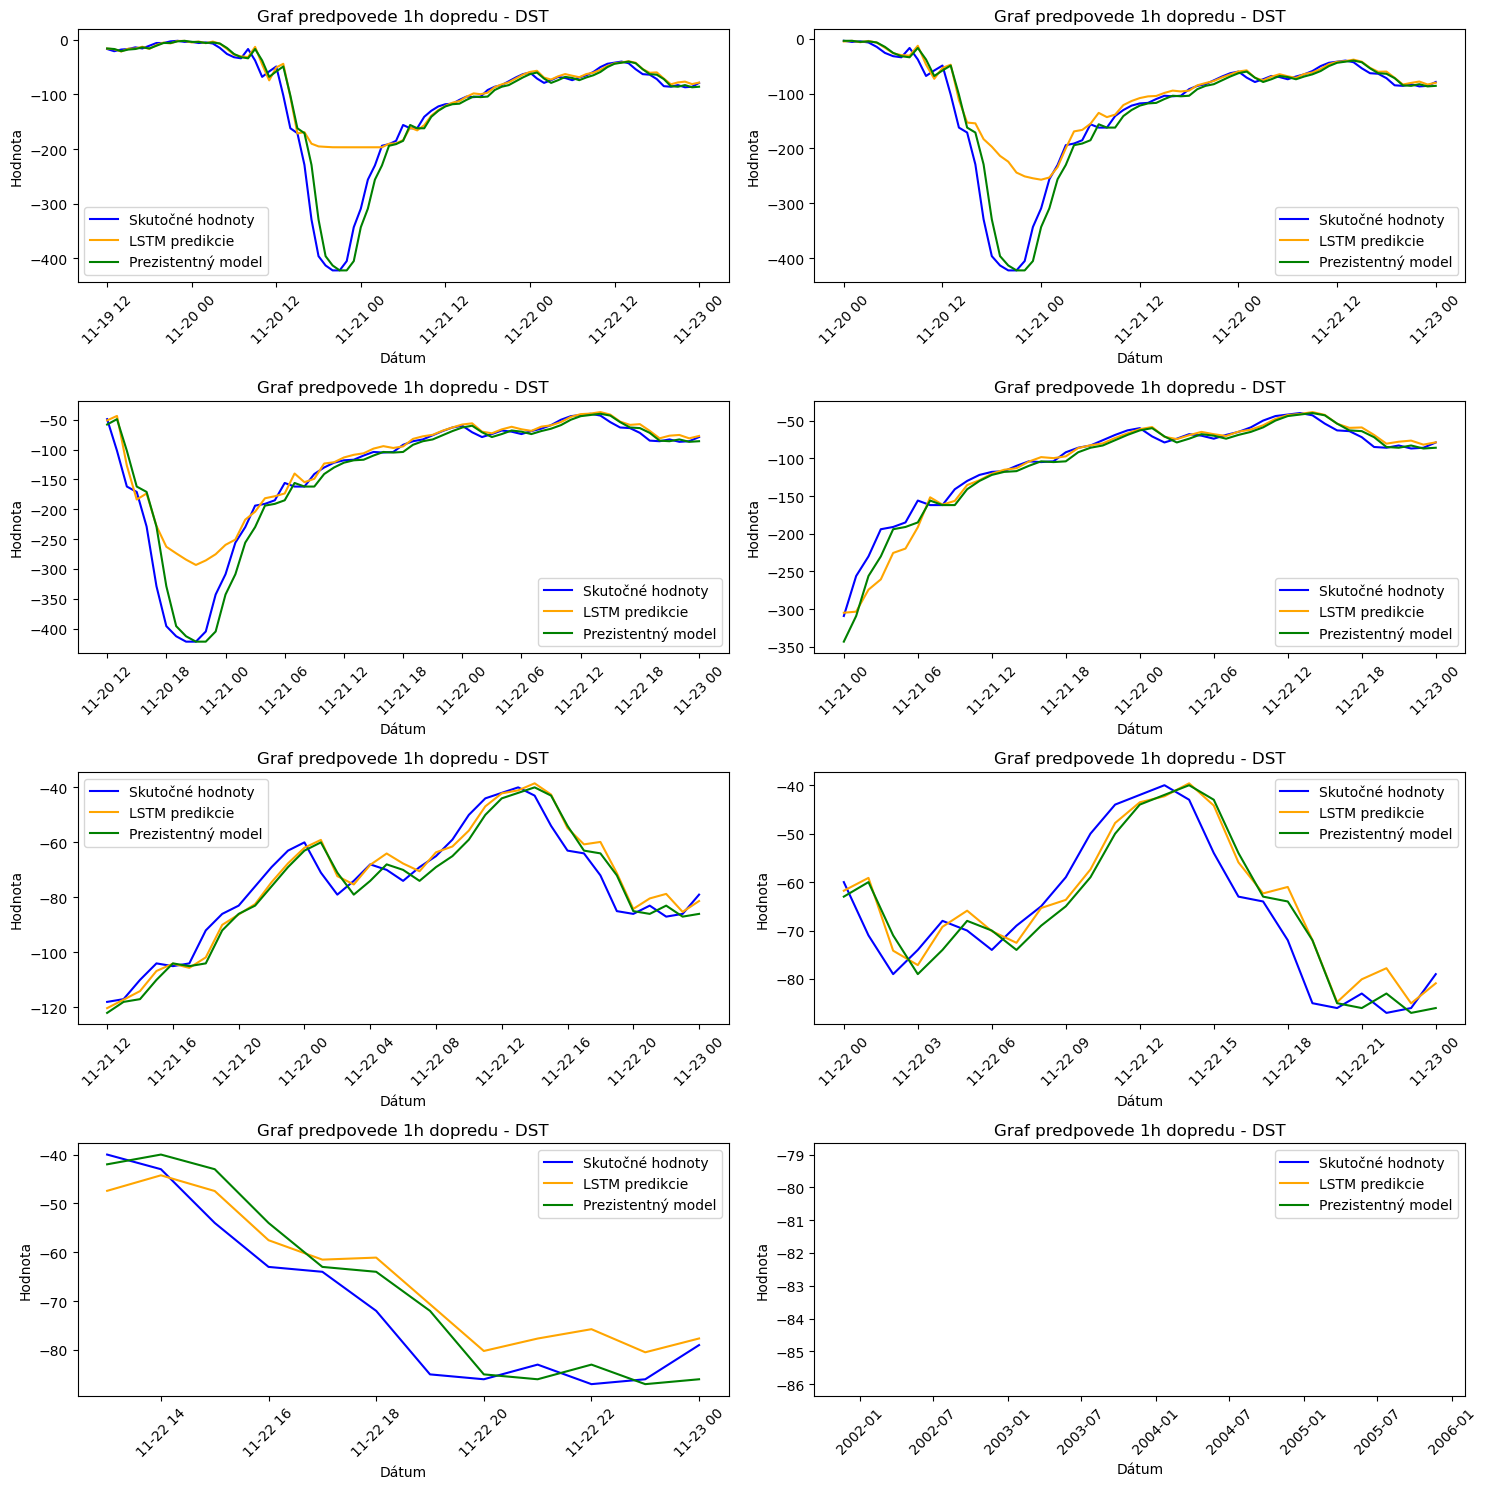

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the date range
start_date = '2003-11-19'
end_date = '2003-11-23'

# Function to load and filter dataframes from CSV files
def load_dataframes():
    dataframes = []
    for i in range(6, 49, 6):  # 6, 12, ..., 48
        filename = f'prediction_comparison_DST+1_LSTM_{i}H.csv'
        df = pd.read_csv(filename, parse_dates=['time'])
        # Filter by the specified date range
        df = df[(df['time'] >= start_date) & (df['time'] <= end_date)]
        dataframes.append(df)
    return dataframes

# Load data
dataframes = load_dataframes()

# Plotting the combined graph
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 15))
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    ax.plot(dataframes[i]['time'], dataframes[i]['y_true'], label='Skutočné hodnoty', color="blue")
    ax.plot(dataframes[i]['time'], dataframes[i]['y_predict'], label='LSTM predikcie', color="orange")
    if 'y_persistance' in dataframes[i].columns:
        ax.plot(dataframes[i]['time'], dataframes[i]['y_persistance'], label='Prezistentný model', color="green")
    ax.set_title(f'Graf predpovede 1h dopredu - DST')
    ax.set_xlabel('Dátum')
    ax.set_ylabel('Hodnota')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("graf_BP_rozne_casy_1.png")
plt.show()
